# Random Search for Nonlinear Data Fitting

This notebook demonstrates a simple **random search** (also known as **Monte Carlo search**) algorithm to fit a nonlinear model to noisy observed data.

### The Problem

We are given noisy observations $d_{\text{obs}}(x)$ generated from the underlying model:

$$
d(x) = \sin(\omega_0 \, m_1 \, x) + m_1 \, m_2 + \epsilon
$$

where:
- $\omega_0 = 1$ (known angular frequency),
- $m_1$ and $m_2$ are the unknown model parameters to be estimated,
- $\epsilon$ is Gaussian noise with standard deviation $\sigma = 0.1$.

Our goal is to recover good estimates of the **true model parameters** $m_1$ and $m_2$ by minimizing the misfit between the observed data and the data predicted by a trial model.

### Method: Random (Monte Carlo) Search

Instead of using sophisticated optimization techniques (such as gradient descent or Levenberg-Marquardt), we use a very basic but intuitive approach:

1. Repeatedly draw **random trial models** $(m_1^{\text{trial}}, m_2^{\text{trial}})$ uniformly from the search ranges $[0, 5]$ for both parameters.
2. For each trial model, compute the **predicted data**:
   $$
   d_{\text{trial}}(x) = \sin(\omega_0 \, m_1^{\text{trial}} \, x) + m_1^{\text{trial}} \, m_2^{\text{trial}}
   $$
3. Calculate the **prediction error** (misfit) using the normalized sum of squared residuals:
   $$
   E = \frac{1}{\sigma} \sum_{i=1}^{N} \left( d_{\text{obs}}(x_i) - d_{\text{trial}}(x_i) \right)^2
   $$
4. If the new trial has a **lower error** than the best solution found so far, accept it as the new best model.

This is a pure **global random search** method. It does not use any gradient information and relies entirely on random sampling and keeping the best solution encountered.

### Why this approach?

- Extremely simple to implement and understand.
- Works for highly nonlinear or even discontinuous problems where gradient-based methods may fail.
- Serves as a baseline to compare against more efficient optimization algorithms.
- Illustrates the core idea of **exploration** in the model space.

### Limitations

- Very inefficient for high-dimensional problems (requires many more iterations as the number of parameters increases).
- Convergence is slow and not guaranteed to find the global minimum.
- The quality of the solution depends strongly on the number of iterations (`N_iter`) and the chosen search bounds.

### Code Overview

The Python code below implements the random search algorithm described above:

- Generates synthetic observed data with added Gaussian noise.
- Runs `10,000` random trials.
- Keeps track of the model with the lowest error.
- Plots the observed data versus the best-fitting model.

After running the cell, you will see:
- The best-fit parameters $m_1$ and $m_2$ found by the algorithm.
- A plot comparing the noisy observations with the recovered model.

---

**Now run the code cell below to perform the random search and visualize the result.**

Best fit parameters: m1 = 2.00, m2 = 3.03
Best fit model: d = sin(1.0*2.00*x) + 2.00*3.03


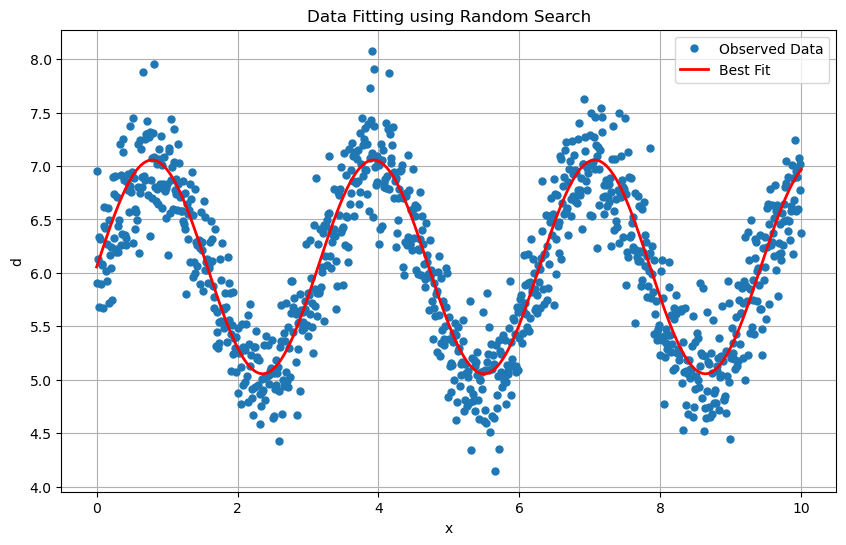

In [ ]:
import numpy as np
N_iter = int(1e4)
m1min = 0
m1max = 5
m2min = 0
m2max = 5
w0 = 1
std = 0.1 # this is the std of the noise in the observed data
x = np.linspace(0,10,1000); 
data_vector = lambda m1,m2: np.array([m1,m2]); #gda is a function that converts model parameters to a vector form . lambda is eigenvalues of the function . 
dobs = np.sin(w0*2.0*x) + 2.0*3.0 + np.random.normal(loc=0.0,scale=np.sqrt(std),size=x.shape); # random observed data with noise
E0 = np.inf; #initial error is the value of the error function for the initial model parameters. Here set to infinity so that any trial solution will be accepted as the new best solution.
# true model parameters
for i in range(1,N_iter):
    # randomly select trial solution
    m1trial = np.random.uniform(low=m1min,high=m1max);
    m2trial = np.random.uniform(low=m2min,high=m2max);
    mtrial = data_vector( m1trial, m2trial );
    # predict data
    dtrial = np.sin(w0*m1trial*x) + m1trial*m2trial;
    # prediction error
    etrial = dobs-dtrial; #observed data minus predicted data
    Etrial = np.matmul(etrial.T,etrial)/std; #predicted error . matmul is matrix multiplication . etrial.T is the transpose of the error vector . etrial.T*etrial is the sum of squares of the errors . dividing by std gives a normalized error measure.
    # accept trial solution if error decreases
    if( Etrial<E0 ):
        # reset best-solution so far to this one
        E0=Etrial;
        m0 = mtrial;

#resulting model: 
print("Best fit parameters: m1 = {:.2f}, m2 = {:.2f}".format(m0[0], m0[1]))
#The model in algebraic form is: d = sin(w0*m1*x) + m1*m2
print("Best fit model: d = sin({:.1f}*{:.2f}*x) + {:.2f}*{:.2f}".format(w0, m0[0], m0[0], m0[1]))

#Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(x, dobs, 'o', label='Observed Data', markersize=5)
plt.plot(x, np.sin(w0*m0[0]*x) + m0[0]*m0[1], 'r-', label='Best Fit', linewidth=2)
plt.xlabel('x')
plt.ylabel('d')
plt.title('Data Fitting using Random Search')
plt.legend()
plt.grid()
plt.show()